## Appended the files using Power Query in MS Excel and splitted columns (experience), did some cleaning and removed Job_Educational_requirements column. as it is giving misleading values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns

In [2]:
df= pd.read_csv(r"C:\Users\alpan\anaconda_projects\d066b04f-01a6-47f1-bb97-d2502c45bac7\naukri_all_jobslist.csv",encoding="latin-1")
df.head()

,Titles,Min.Experience,Max.Experience,Location,Company_name,Skills_required,Total_reviews.1,Rating,job_post_day
0,Advanced Data Science Consultant,6.0,9.0,Hybrid - Pune,ZS,data scienceData EngineeringEngineering ToolsR...,2725.0,3.1,3 weeks ago
1,Advanced Data Science Consultant,6.0,9.0,Gurugram,ZS,data scienceData EngineeringEngineering ToolsR...,2725.0,3.1,3 weeks ago
2,Advanced Data Science Consultant,6.0,9.0,Bengaluru,ZS,data scienceData EngineeringEngineering ToolsR...,2725.0,3.1,3 weeks ago
3,Urgent: Job Opportunity with PWC-AC-Data scien...,4.0,8.0,Hybrid - Kolkata,PwC Service Delivery Center,Data SciencePythonAI MLCloudMachine LearningAr...,12482.0,3.3,1 day ago
4,Urgent: Job Opportunity with PWC-AC-Data scien...,4.0,8.0,Hyderabad,PwC Service Delivery Center,Data SciencePythonAI MLCloudMachine LearningAr...,12482.0,3.3,1 day ago


In [3]:
df.columns

Index(['Titles', 'Min.Experience', 'Max.Experience', 'Location',
       'Company_name', 'Skills_required', 'Total_reviews.1', 'Rating',
       'job_post_day'],
      dtype='object')

In [4]:
df.shape

(2417, 9)

## Data Cleaning and preprocessing 

### 1. Handling missing values 

In [5]:
df.isnull().sum()

Titles               0
Min.Experience      76
Max.Experience      76
Location             6
Company_name       557
Skills_required     71
Total_reviews.1    557
Rating             557
job_post_day         0
dtype: int64

In [6]:
df = df.dropna(subset=["Min.Experience", "Max.Experience","Location","Company_name", "Skills_required",
                       "Total_reviews.1","Rating"])

In [7]:
df.isnull().sum()

Titles             0
Min.Experience     0
Max.Experience     0
Location           0
Company_name       0
Skills_required    0
Total_reviews.1    0
Rating             0
job_post_day       0
dtype: int64

In [8]:
df.shape

(1802, 9)

### 2. Handling duplicate records

In [9]:
df.columns

Index(['Titles', 'Min.Experience', 'Max.Experience', 'Location',
       'Company_name', 'Skills_required', 'Total_reviews.1', 'Rating',
       'job_post_day'],
      dtype='object')

In [10]:
df.duplicated(subset=['Titles', 'Min.Experience', 'Max.Experience', 'Location',
       'Company_name', 'Skills_required','Total_reviews.1', 'Rating', 'job_post_day']).sum()

np.int64(7)

In [11]:
df.drop_duplicates(subset=['Titles', 'Min.Experience', 'Max.Experience', 'Location',
       'Company_name', 'Skills_required',
       'Total_reviews.1', 'Rating', 'job_post_day'], inplace=True)
df.shape

(1795, 9)

### 3. Inconsistent formats 

### Skills required

#### In Skills required the values are messy it needs to be cleaned or to be in well format to be understood easily.

In [12]:
df['Skills_required'].value_counts()

Skills_required
metadatapythondata analysisdata managementdata analyticsdata validationconfigurationdata mining                                                            25
algorithmspythonmodelingdata analysisdata analyticsnatural language processingpredictivemachine learning                                                   24
master datametadatapythondata analysisdata managementdata analyticsdata validationconfiguration                                                            14
Trainingdeep learningTeam managementdata scienceGCPMachine learningDeploymentMonitoring                                                                    10
Machine LearningPythonMatplotlibJupyter NotebookDeep LearningNumpyScikit-LearnSQL                                                                           9
                                                                                                                                                           ..
SQL queriesAutomationData management

#### As the data is huge i will create a master of skill sets and then use skill dictionary to search for the skill in the skill required column.

In [13]:
skills_master = [
    "python","sql","machine learning","deep learning",
    "natural language processing","data science","data engineering",
    "data analysis","pandas","numpy","tensorflow","pytorch",
    "azure","aws", "computer vision", "tableau","power bi","excel","statistics","Predictive modeling",
    "time series","git", "kubernetes","docker","llm","generative ai","Data modelling","rca", "ai solutions", 
    "ai cloud platforms", "artificial intelligence",
    "Data visualisation", "Data processing","python libraries","Statistical analysis"
]

#### Using re library i clean the text and convert it into lower case .

In [14]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    return text

#### then create a function extract-skills and if the same skill is found on text(skill required column) it will be stored in found list and then match it with the clean column where cleaned records are stoered.

In [15]:
def extract_skills(text):
    found = []
    for skill in skills_master:
        if skill in text:
            found.append(skill)
    return found

df['clean'] = df['Skills_required'].apply(clean_text)
df['skills_extracted'] = df['clean'].apply(extract_skills)

#### Once the skills are matching with the skill reuired (clean) column and the extracted skills we'll count the skills

In [16]:
from collections import Counter

all_skills = []
for row in df['skills_extracted']:
    all_skills.extend(row)

top_skills = Counter(all_skills)
top_skills_df = pd.DataFrame(top_skills.items(), columns=['Skill','Count']) \
                    .sort_values(by='Count', ascending=False)

top_skills_df.head(10)

,Skill,Count
3,machine learning,840
2,python,821
0,data science,651
5,data analysis,548
6,sql,360
13,natural language processing,295
4,artificial intelligence,233
7,power bi,231
9,deep learning,169
8,azure,85


#### “I flattened the extracted skill lists and used a frequency count to identify the most in-demand skills across job postings.”

In [17]:
df.head()

,Titles,Min.Experience,Max.Experience,Location,Company_name,Skills_required,Total_reviews.1,Rating,job_post_day,clean,skills_extracted
0,Advanced Data Science Consultant,6.0,9.0,Hybrid - Pune,ZS,data scienceData EngineeringEngineering ToolsR...,2725.0,3.1,3 weeks ago,data sciencedata engineeringengineering toolsr...,"[data science, data engineering]"
1,Advanced Data Science Consultant,6.0,9.0,Gurugram,ZS,data scienceData EngineeringEngineering ToolsR...,2725.0,3.1,3 weeks ago,data sciencedata engineeringengineering toolsr...,"[data science, data engineering]"
2,Advanced Data Science Consultant,6.0,9.0,Bengaluru,ZS,data scienceData EngineeringEngineering ToolsR...,2725.0,3.1,3 weeks ago,data sciencedata engineeringengineering toolsr...,"[data science, data engineering]"
3,Urgent: Job Opportunity with PWC-AC-Data scien...,4.0,8.0,Hybrid - Kolkata,PwC Service Delivery Center,Data SciencePythonAI MLCloudMachine LearningAr...,12482.0,3.3,1 day ago,data sciencepythonai mlcloudmachine learningar...,"[python, machine learning, data science, artif..."
4,Urgent: Job Opportunity with PWC-AC-Data scien...,4.0,8.0,Hyderabad,PwC Service Delivery Center,Data SciencePythonAI MLCloudMachine LearningAr...,12482.0,3.3,1 day ago,data sciencepythonai mlcloudmachine learningar...,"[python, machine learning, data science, artif..."


In [18]:
df_exploded = df.explode('skills_extracted')
df_exploded['skills_extracted'] = df_exploded['skills_extracted'].str.lower().str.strip()

In [19]:
skill_counts = df_exploded['skills_extracted'].value_counts()

In [20]:
df['skills_extracted'].value_counts()

skills_extracted
[]                                                                            101
[data analysis]                                                                80
[machine learning, data science]                                               69
[data science]                                                                 64
[python, data analysis]                                                        63
                                                                             ... 
[python, sql, data science, excel]                                              1
[data science, data analysis, power bi, git]                                    1
[python, machine learning, natural language processing, kubernetes]             1
[machine learning, data science, computer vision, artificial intelligence]      1
[python, machine learning, data science, data analysis, numpy]                  1
Name: count, Length: 501, dtype: int64

#### Blank space [  ] is there in the values so these blank values is replaced by vdata science as it is the most required skill in data science job.

In [21]:
df['skills_extracted'] = df['skills_extracted'].apply(lambda x: x if len(x) > 2 else ['data science'])
df['skills_extracted'].value_counts()

skills_extracted
[data science]                                                                                             805
[python, machine learning, natural language processing, data analysis]                                      32
[python, machine learning, data science]                                                                    26
[machine learning, deep learning, data science]                                                             22
[python, deep learning, natural language processing, data science, computer vision]                         21
                                                                                                          ... 
[python, sql, machine learning, natural language processing, data engineering, artificial intelligence]      1
[machine learning, data analysis, computer vision]                                                           1
[sql, deep learning, numpy, tensorflow]                                                        

In [22]:
df_exploded['skills_extracted'].value_counts()

skills_extracted
machine learning               840
python                         821
data science                   651
data analysis                  548
sql                            360
natural language processing    295
artificial intelligence        233
power bi                       231
deep learning                  169
azure                           85
git                             85
generative ai                   73
data engineering                71
numpy                           69
computer vision                 62
tableau                         62
tensorflow                      59
excel                           56
statistics                      54
aws                             47
kubernetes                      39
ai solutions                    36
llm                             34
time series                     32
pytorch                         26
docker                          10
rca                              5
pandas                           4
Nam

In [23]:
df.shape

(1795, 11)

### Location

In [24]:
df['Location'].value_counts()

Location
Bengaluru                         505
Hyderabad                         153
Gurugram                          150
 Bengaluru                        108
Chennai                           104
                                 ... 
Thane                               1
 Lucknow                            1
Pune(Viman Nagar)                   1
Bengaluru(Sector 7 HSR Layout)      1
 Kursela                            1
Name: count, Length: 130, dtype: int64

#### Location names are not is correct format, this column also requires processing.

In [25]:
df['Location'] = df['Location'].str.lower().str.strip()

In [26]:
location_map = {
    'new delhi': 'delhi',
    'delhi ncr': 'delhi',
    'delhi / ncr':'noida',
    'bangalore': 'bengaluru',
    'navi mumbai': 'mumbai',
    'india':'remote',
    'hybrid - hyderabad':'hyderabad',
    'hybrid - bengaluru':'bengaluru',
    'hybrid - pune':'pune',
    'hybrid - gurugram':'gurugram',
    'hybrid - chennai':'chennai',
    'hybrid - kolkata':'kolkata',
    'mumbai (all areas)': 'mumbai',
    'hybrid - bengaluru(koramangala)':'bengaluru',
    'hybrid - mumbai (all areas)':'mumbai'
    
}

df['Location'] = df['Location'].str.lower().replace(location_map)

In [27]:
df['Location'].value_counts()

Location
bengaluru                         634
hyderabad                         202
gurugram                          182
pune                              155
chennai                           152
                                 ... 
nashik                              1
thane                               1
pune(viman nagar)                   1
bengaluru(sector 7 hsr layout)      1
kursela                             1
Name: count, Length: 97, dtype: int64

## 4. Feature engineering 

### Experience level

### Segmented jobs based on minimum experience into Entry level, mid level and senior level.

In [28]:
df.describe()

,Min.Experience,Max.Experience,Total_reviews.1,Rating
count,1795.000000,1795.000000,1795.000000,1795.000000
mean,4.532033,8.432869,14257.141504,3.598050
std,3.115118,3.879789,26956.294329,0.498215
min,0.000000,1.000000,2.000000,1.000000
25%,2.000000,6.000000,62.000000,3.400000
50%,4.000000,8.000000,704.000000,3.700000
75%,6.000000,10.000000,8566.000000,3.900000
max,20.000000,30.000000,113460.000000,5.000000


In [29]:
def exp_level(row):
    if row['Min.Experience'] >=0  and row['Max.Experience'] <= 3:
        return 'Entry level'
    elif row['Min.Experience'] >= 4 and row['Max.Experience'] <= 10:
        return 'Mid level'
    else:
        return 'Senior level'

df['experience_level'] = df.apply(exp_level, axis=1)
df['experience_level']

0          Mid level
1          Mid level
2          Mid level
3          Mid level
4          Mid level
            ...     
2412    Senior level
2413    Senior level
2414    Senior level
2415    Senior level
2416    Senior level
Name: experience_level, Length: 1795, dtype: object

In [30]:
df.columns

Index(['Titles', 'Min.Experience', 'Max.Experience', 'Location',
       'Company_name', 'Skills_required', 'Total_reviews.1', 'Rating',
       'job_post_day', 'clean', 'skills_extracted', 'experience_level'],
      dtype='object')

In [31]:
df['experience_level'].value_counts()

experience_level
Senior level    1009
Mid level        623
Entry level      163
Name: count, dtype: int64

### Top 10 Locations

In [32]:
top_locs = df['Location'].value_counts().head(10).index

df['location_group'] = df['Location'].apply(
    lambda x: x if x in top_locs else 'Others')
df['location_group'].value_counts()

location_group
bengaluru    634
hyderabad    202
Others       192
gurugram     182
pune         155
chennai      152
mumbai       115
delhi         55
remote        41
kolkata       36
noida         31
Name: count, dtype: int64

In [33]:
df.columns

Index(['Titles', 'Min.Experience', 'Max.Experience', 'Location',
       'Company_name', 'Skills_required', 'Total_reviews.1', 'Rating',
       'job_post_day', 'clean', 'skills_extracted', 'experience_level',
       'location_group'],
      dtype='object')

### Review Segment

#### Total reviews from the jobs are segmente into 3 groups Low reviews, Medium reviews, High reviews

In [34]:
df.describe()

,Min.Experience,Max.Experience,Total_reviews.1,Rating
count,1795.000000,1795.000000,1795.000000,1795.000000
mean,4.532033,8.432869,14257.141504,3.598050
std,3.115118,3.879789,26956.294329,0.498215
min,0.000000,1.000000,2.000000,1.000000
25%,2.000000,6.000000,62.000000,3.400000
50%,4.000000,8.000000,704.000000,3.700000
75%,6.000000,10.000000,8566.000000,3.900000
max,20.000000,30.000000,113460.000000,5.000000


#### Rather than guessing the threshold, Here qcut used to segment the data (rows) into approx 33% in each segment.

In [35]:
df['review_segment'] = pd.qcut(
    df['Total_reviews.1'],
    q=3,
    labels=['Low', 'Medium', 'High'])

In [36]:
df['review_segment'].value_counts()

review_segment
Low       624
High      597
Medium    574
Name: count, dtype: int64

### Rating

In [37]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

In [38]:
df['rating_segment'] = pd.qcut(
    df['Rating'],
    q=3,
    labels=['Low', 'Medium', 'High'])

In [39]:
df['rating_segment'].value_counts()

rating_segment
Low       724
Medium    571
High      500
Name: count, dtype: int64

## Exploratory Data Analysis & Visualization

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1795 entries, 0 to 2416
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Titles            1795 non-null   object  
 1   Min.Experience    1795 non-null   float64 
 2   Max.Experience    1795 non-null   float64 
 3   Location          1795 non-null   object  
 4   Company_name      1795 non-null   object  
 5   Skills_required   1795 non-null   object  
 6   Total_reviews.1   1795 non-null   float64 
 7   Rating            1795 non-null   float64 
 8   job_post_day      1795 non-null   object  
 9   clean             1795 non-null   object  
 10  skills_extracted  1795 non-null   object  
 11  experience_level  1795 non-null   object  
 12  location_group    1795 non-null   object  
 13  review_segment    1795 non-null   category
 14  rating_segment    1795 non-null   category
dtypes: category(2), float64(4), object(9)
memory usage: 200.1+ KB


In [41]:
df.shape

(1795, 15)

#### Statistical Analysis

In [42]:
df.describe()

,Min.Experience,Max.Experience,Total_reviews.1,Rating
count,1795.000000,1795.000000,1795.000000,1795.000000
mean,4.532033,8.432869,14257.141504,3.598050
std,3.115118,3.879789,26956.294329,0.498215
min,0.000000,1.000000,2.000000,1.000000
25%,2.000000,6.000000,62.000000,3.400000
50%,4.000000,8.000000,704.000000,3.700000
75%,6.000000,10.000000,8566.000000,3.900000
max,20.000000,30.000000,113460.000000,5.000000


#### Null Values

In [43]:
df.isnull().sum()

Titles              0
Min.Experience      0
Max.Experience      0
Location            0
Company_name        0
Skills_required     0
Total_reviews.1     0
Rating              0
job_post_day        0
clean               0
skills_extracted    0
experience_level    0
location_group      0
review_segment      0
rating_segment      0
dtype: int64

#### Renaming of Columnnames

In [44]:
df.columns

Index(['Titles', 'Min.Experience', 'Max.Experience', 'Location',
       'Company_name', 'Skills_required', 'Total_reviews.1', 'Rating',
       'job_post_day', 'clean', 'skills_extracted', 'experience_level',
       'location_group', 'review_segment', 'rating_segment'],
      dtype='object')

In [45]:
df.rename(columns= {'Titles':'Job_title', 'Min.Experience':'Min_Experience', 'Max.Experience':'Max_Experience',
       'Total_reviews.1': 'Total_reviews','skills_extracted':'skills'},inplace = True )

In [46]:
df.head()

,Job_title,Min_Experience,Max_Experience,Location,Company_name,Skills_required,Total_reviews,Rating,job_post_day,clean,skills,experience_level,location_group,review_segment,rating_segment
0,Advanced Data Science Consultant,6.0,9.0,pune,ZS,data scienceData EngineeringEngineering ToolsR...,2725.0,3.1,3 weeks ago,data sciencedata engineeringengineering toolsr...,[data science],Mid level,pune,Medium,Low
1,Advanced Data Science Consultant,6.0,9.0,gurugram,ZS,data scienceData EngineeringEngineering ToolsR...,2725.0,3.1,3 weeks ago,data sciencedata engineeringengineering toolsr...,[data science],Mid level,gurugram,Medium,Low
2,Advanced Data Science Consultant,6.0,9.0,bengaluru,ZS,data scienceData EngineeringEngineering ToolsR...,2725.0,3.1,3 weeks ago,data sciencedata engineeringengineering toolsr...,[data science],Mid level,bengaluru,Medium,Low
3,Urgent: Job Opportunity with PWC-AC-Data scien...,4.0,8.0,kolkata,PwC Service Delivery Center,Data SciencePythonAI MLCloudMachine LearningAr...,12482.0,3.3,1 day ago,data sciencepythonai mlcloudmachine learningar...,"[python, machine learning, data science, artif...",Mid level,kolkata,High,Low
4,Urgent: Job Opportunity with PWC-AC-Data scien...,4.0,8.0,hyderabad,PwC Service Delivery Center,Data SciencePythonAI MLCloudMachine LearningAr...,12482.0,3.3,1 day ago,data sciencepythonai mlcloudmachine learningar...,"[python, machine learning, data science, artif...",Mid level,hyderabad,High,Low


#### Dropping unnecessary columns

In [47]:
df.drop(columns=['clean','Skills_required'],inplace=True)

In [48]:
df.columns

Index(['Job_title', 'Min_Experience', 'Max_Experience', 'Location',
       'Company_name', 'Total_reviews', 'Rating', 'job_post_day', 'skills',
       'experience_level', 'location_group', 'review_segment',
       'rating_segment'],
      dtype='object')

### Univariate analysis

In [49]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

In [50]:
num_cols

Index(['Min_Experience', 'Max_Experience', 'Total_reviews', 'Rating'], dtype='object')

In [51]:
cat_cols

Index(['Job_title', 'Location', 'Company_name', 'job_post_day', 'skills',
       'experience_level', 'location_group', 'review_segment',
       'rating_segment'],
      dtype='object')

#### Distribution of Data in numerical columns

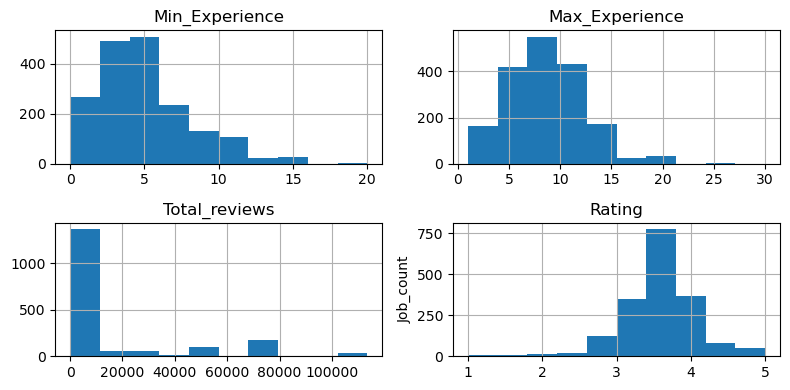

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

df[num_cols].hist(figsize=(8,4))
plt.ylabel("Job_count")
plt.tight_layout()
plt.show()

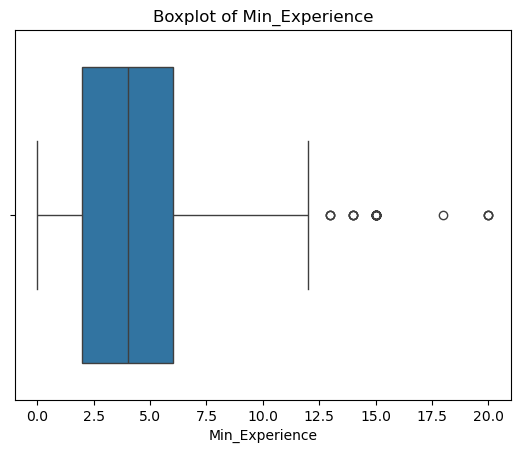

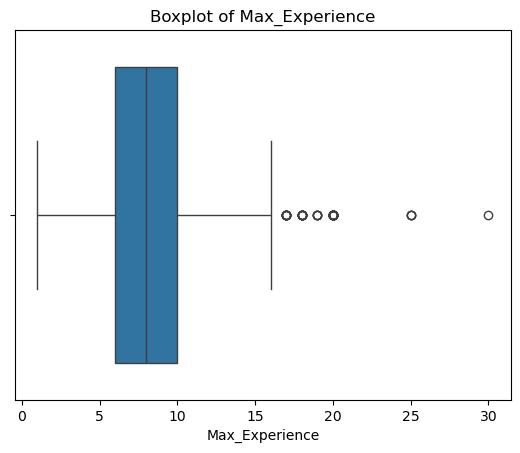

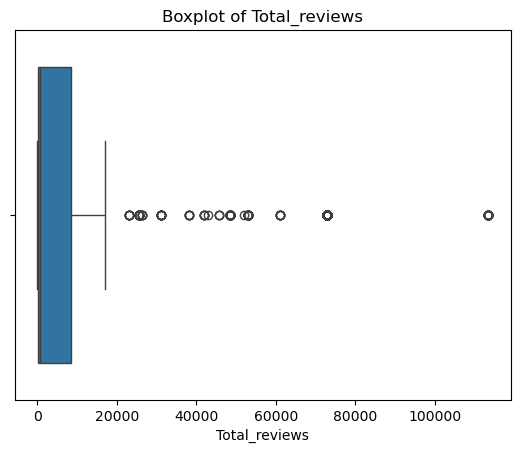

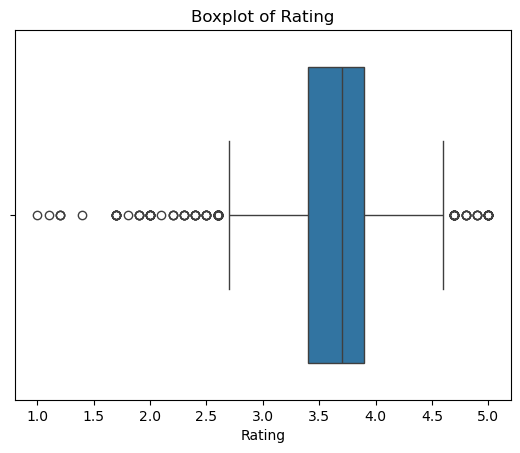

In [53]:
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

#### Distribution of Data in Categorical columns

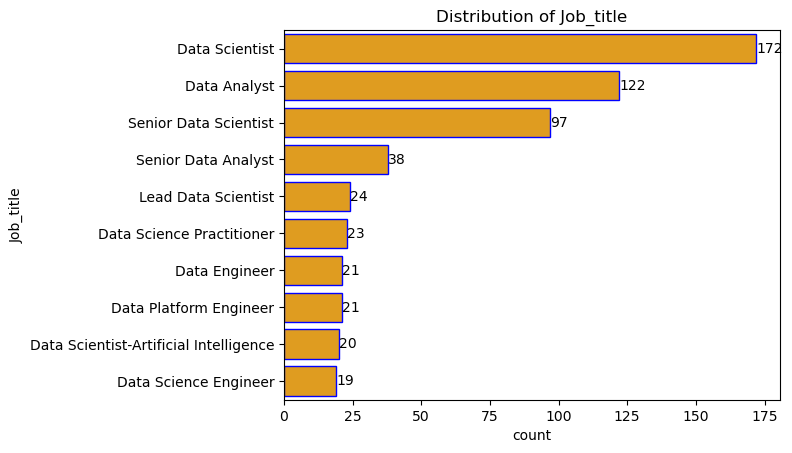

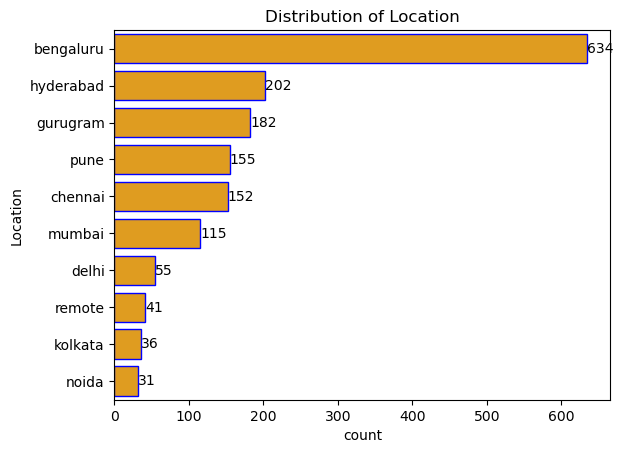

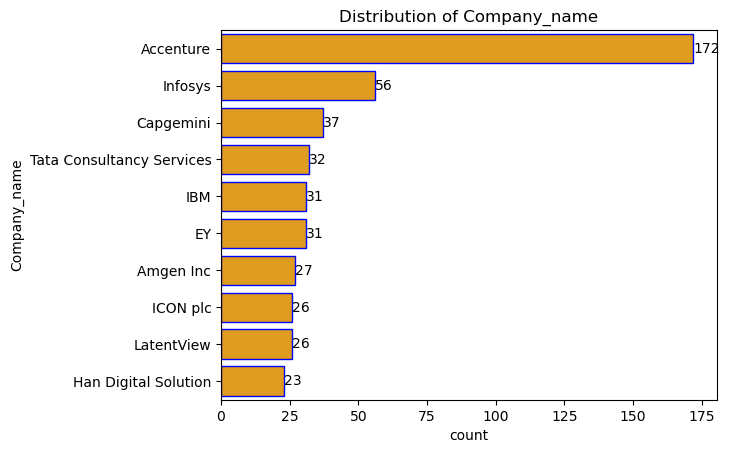

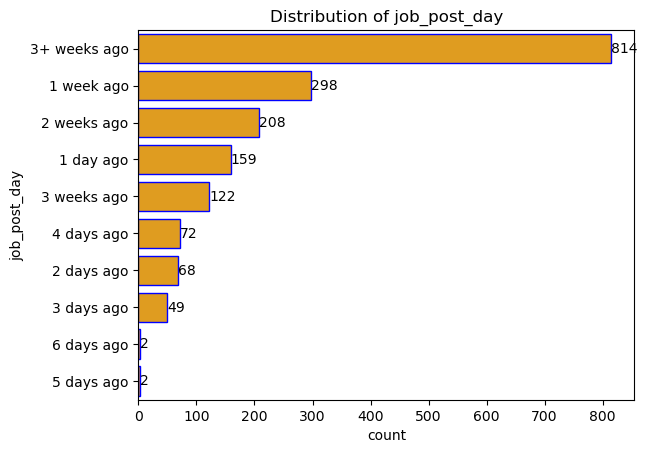

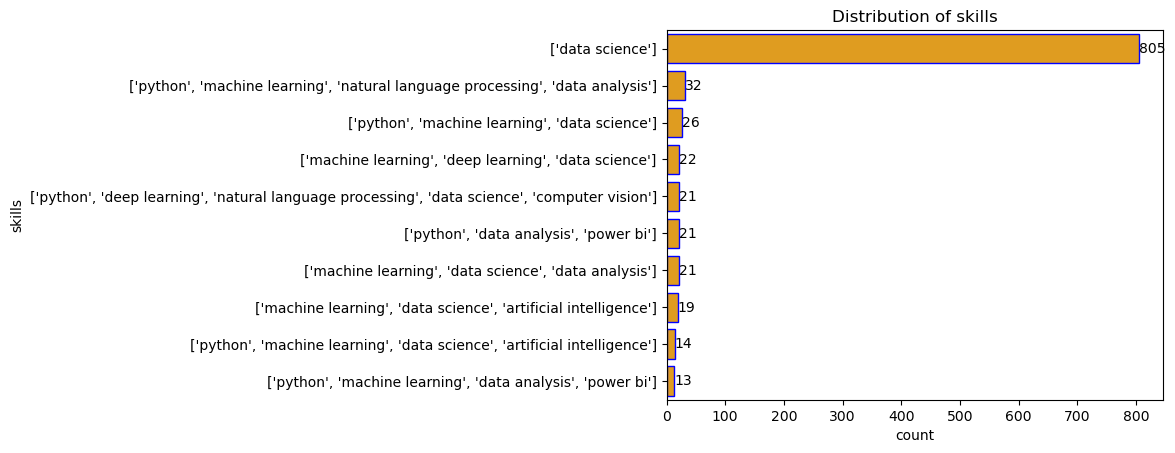

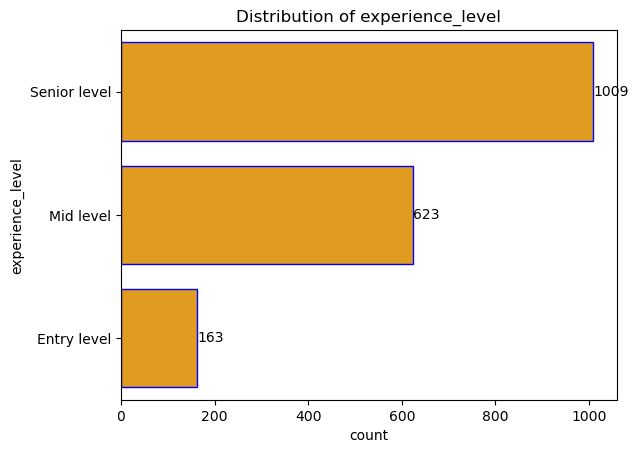

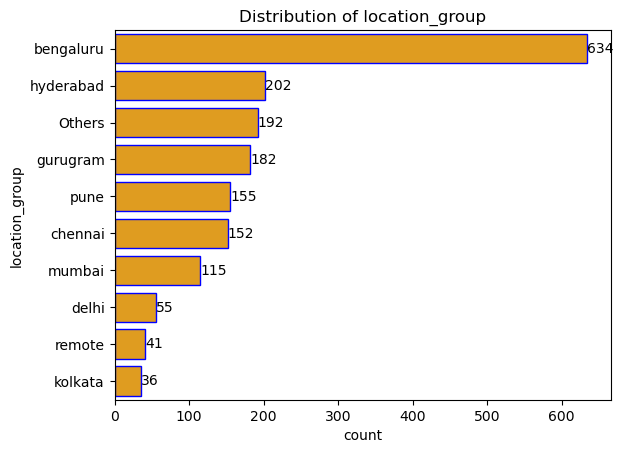

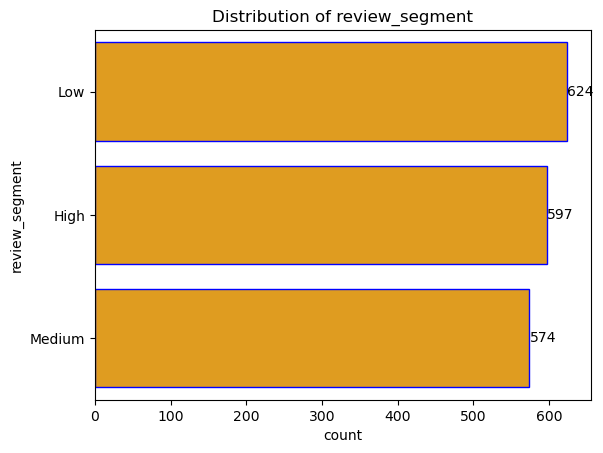

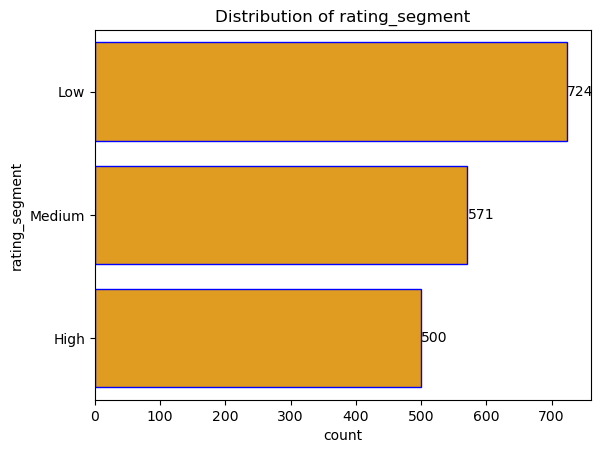

In [54]:
for col in cat_cols:
    cc=sns.countplot(y=col, data=df, order=df[col].value_counts().head(10).index,color = 'orange', edgecolor ='blue')
    cc.bar_label(cc.containers[0])
    plt.yticks(rotation=0)
    plt.title(f'Distribution of {col}')
    plt.show()

### Top Skills

In [55]:
df_exploded = df.explode('skills')
df_exploded['skills'] = df_exploded['skills'].str.lower().str.strip()

In [56]:
top_skills = df_exploded['skills'].value_counts().head(10)

In [57]:
df_exploded['skills'].value_counts()

skills
data science                   1256
machine learning                659
python                          655
data analysis                   323
natural language processing     276
sql                             257
artificial intelligence         214
power bi                        185
deep learning                   161
git                              80
azure                            74
generative ai                    70
numpy                            63
tensorflow                       58
computer vision                  58
tableau                          52
data engineering                 40
statistics                       37
kubernetes                       35
llm                              33
aws                              33
ai solutions                     30
excel                            30
time series                      30
pytorch                          25
docker                           10
pandas                            4
rca                  

In [58]:
top_skills

skills
data science                   1256
machine learning                659
python                          655
data analysis                   323
natural language processing     276
sql                             257
artificial intelligence         214
power bi                        185
deep learning                   161
git                              80
Name: count, dtype: int64

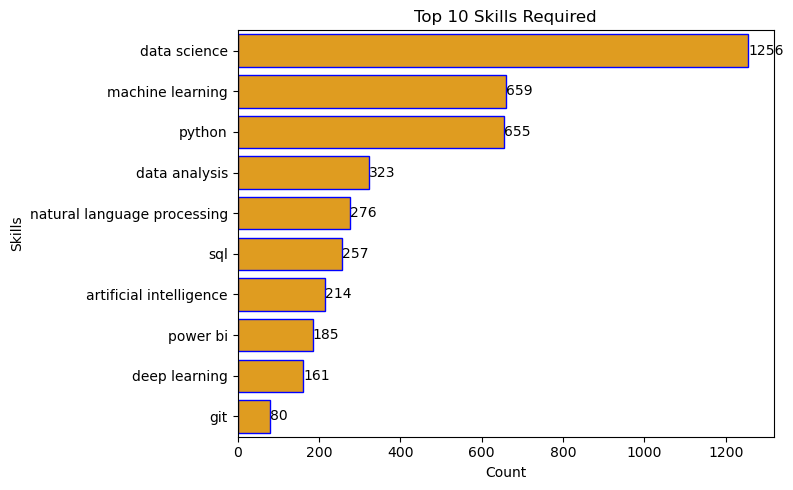

In [59]:
plt.figure(figsize=(8,5))
ax = sns.barplot(y=top_skills.index, x=top_skills.values,color = 'orange', edgecolor ='blue')
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel('Count')
plt.ylabel('Skills')
plt.title('Top 10 Skills Required')
plt.tight_layout()
plt.show()

#### Data Science is the top skill required in the job market for Data Science and Analysis domain, followed by other combinations of skills.

### Total job counts per location 

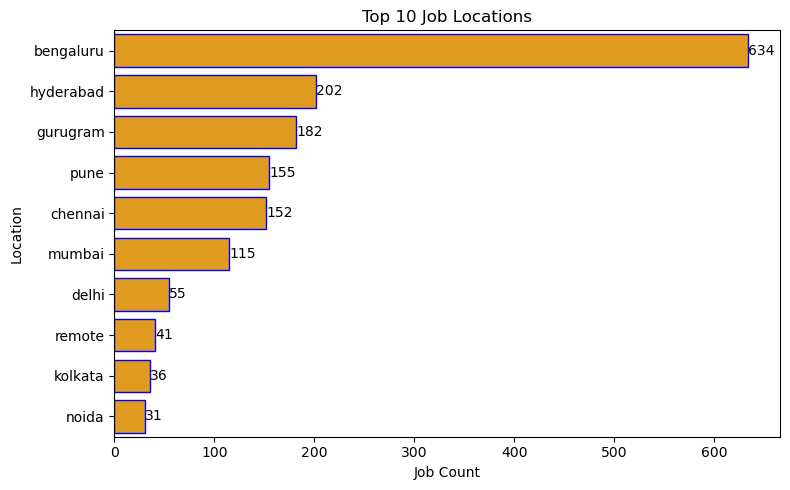

In [60]:
location_counts = df['Location'].value_counts().head(10)
plt.figure(figsize=(8,5))
lc = sns.barplot(x=location_counts.values, y=location_counts.index,color = 'orange', edgecolor ='blue')
for container in lc.containers:
    lc.bar_label(container)
plt.xlabel('Job Count')
plt.ylabel('Location')
plt.title('Top 10 Job Locations')
plt.tight_layout()
plt.show()

####  Bengaluru is the hub of Data Science jobs followed by Hyderabad, Gurugram, and Pune.

### Skills vs Experience

In [67]:
df['avg_exp'] = (df['Min_Experience'] + df['Max_Experience']) / 2
df_exploded = df.explode('skills')
top_skills = df_exploded['skills'].value_counts().head(10).index
df_top = df_exploded[df_exploded['skills'].isin(top_skills)]
skill_exp = df_top.groupby('skills')['avg_exp'].mean().sort_values()

C:\Users\alpan\AppData\Local\Temp\ipykernel_14012\1577631939.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  se = sns.barplot(x=skill_exp.values, y=skill_exp.index,palette='viridis')


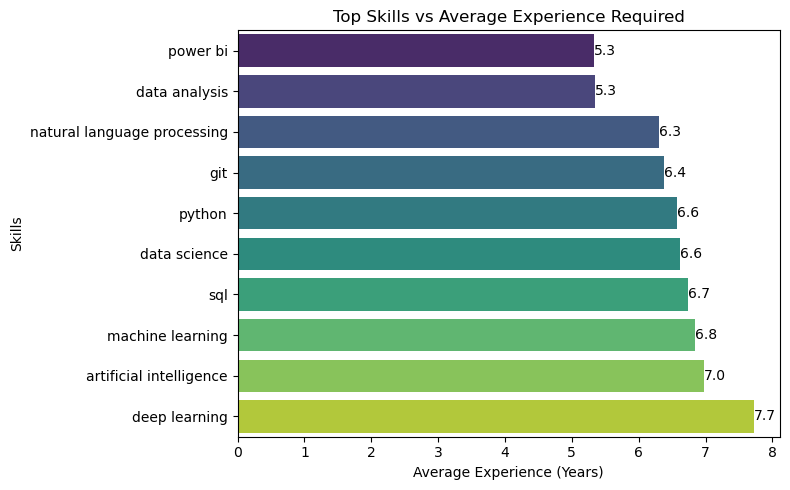

In [68]:
plt.figure(figsize=(8,5))
se = sns.barplot(x=skill_exp.values, y=skill_exp.index,palette='viridis')
for container in se.containers:
    se.bar_label(container, fmt='%.1f')
plt.xlabel('Average Experience (Years)')
plt.ylabel('Skills')
plt.title('Top Skills vs Average Experience Required')
plt.tight_layout()
plt.show()

#### An increase in the number and complexity of required skills correlates with higher experience requirements, highlighting the importance of skill stacking for senior roles.

In [69]:
df.head()

,Job_title,Min_Experience,Max_Experience,Location,Company_name,Total_reviews,Rating,job_post_day,skills,experience_level,location_group,review_segment,rating_segment,avg_exp
0,Advanced Data Science Consultant,6.0,9.0,pune,ZS,2725.0,3.1,3 weeks ago,[data science],Mid level,pune,Medium,Low,7.5
1,Advanced Data Science Consultant,6.0,9.0,gurugram,ZS,2725.0,3.1,3 weeks ago,[data science],Mid level,gurugram,Medium,Low,7.5
2,Advanced Data Science Consultant,6.0,9.0,bengaluru,ZS,2725.0,3.1,3 weeks ago,[data science],Mid level,bengaluru,Medium,Low,7.5
3,Urgent: Job Opportunity with PWC-AC-Data scien...,4.0,8.0,kolkata,PwC Service Delivery Center,12482.0,3.3,1 day ago,"[python, machine learning, data science, artif...",Mid level,kolkata,High,Low,6.0
4,Urgent: Job Opportunity with PWC-AC-Data scien...,4.0,8.0,hyderabad,PwC Service Delivery Center,12482.0,3.3,1 day ago,"[python, machine learning, data science, artif...",Mid level,hyderabad,High,Low,6.0


### Location VS Rating

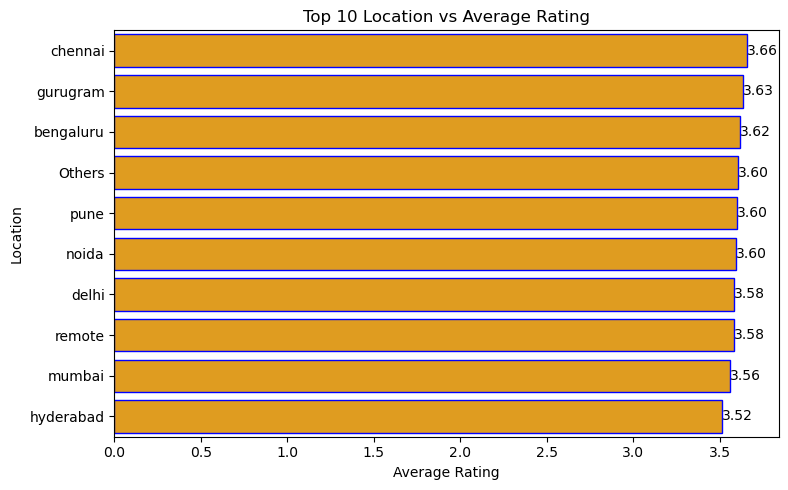

In [70]:
loc_rating = df.groupby('location_group')['Rating'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))
lr = sns.barplot(x=loc_rating.values, y=loc_rating.index,color = 'orange', edgecolor ='blue')
for container in lr.containers:
    lr.bar_label(container, fmt= '%.2f')
plt.xlabel('Average Rating')
plt.ylabel('Location')
plt.title('Top 10 Location vs Average Rating')
plt.tight_layout()
plt.show()

#### Location-based rating analysis suggests that while metro cities dominate hiring, smaller locations (others) may offer comparatively better work satisfaction, though this could be influenced by sample size bias. 

### Job title VS Experience level

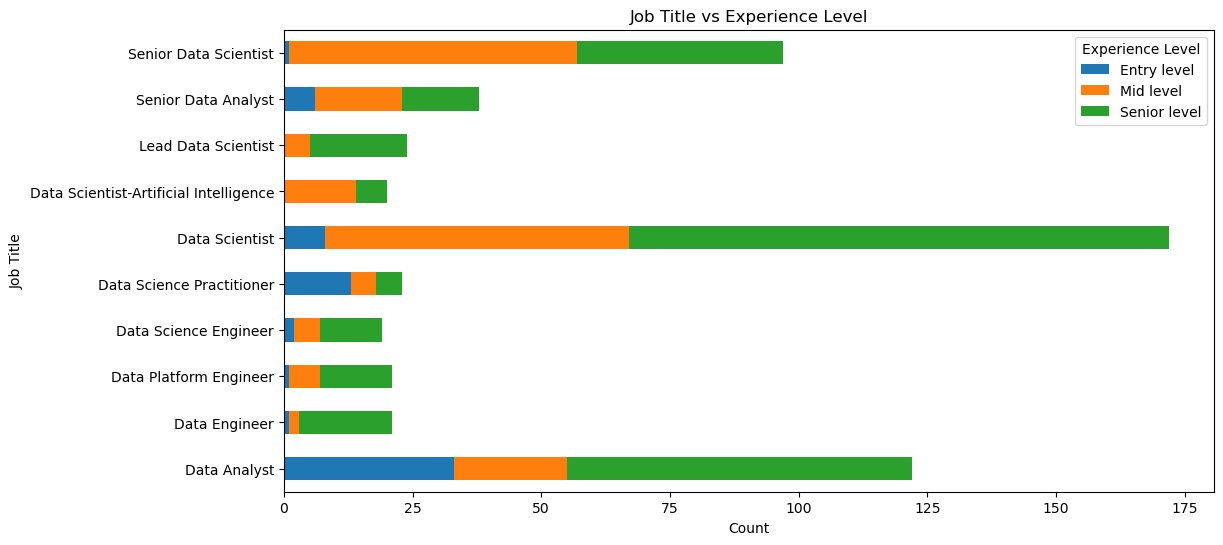

In [71]:
top_roles = df['Job_title'].value_counts().head(10).index
df_filtered = df[df['Job_title'].isin(top_roles)]
ct = pd.crosstab(df_filtered['Job_title'], df_filtered['experience_level'])

ct.plot(kind='barh', stacked=True, figsize=(12,6))

plt.title('Job Title vs Experience Level')
plt.xlabel('Count')
plt.ylabel('Job Title')
plt.legend(title='Experience Level')
plt.show()

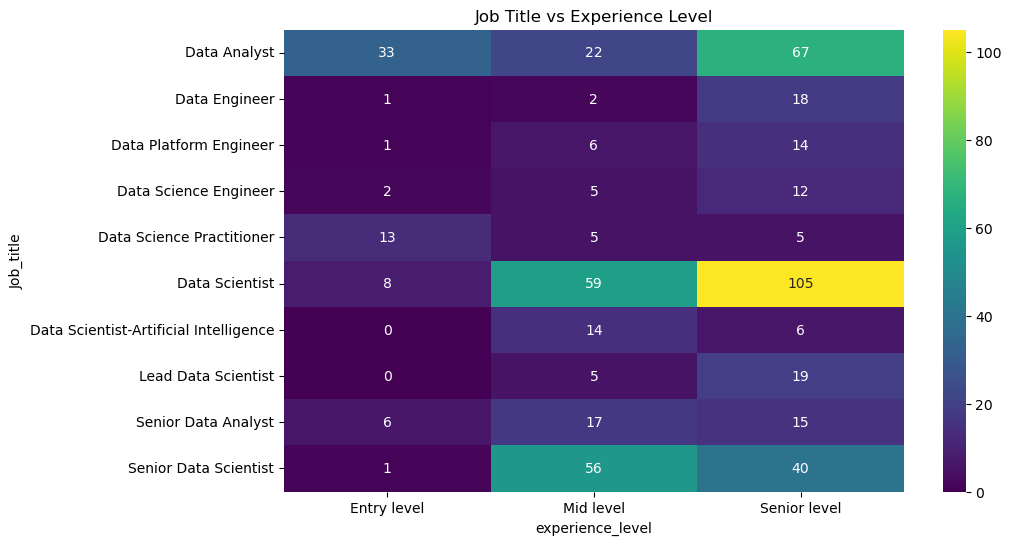

In [72]:
ct = pd.crosstab(df_filtered['Job_title'], df_filtered['experience_level'])

plt.figure(figsize=(10,6))
sns.heatmap(ct, annot=True, fmt='d', cmap='viridis')

plt.title('Job Title vs Experience Level')
plt.show()

#### --> Most Data Analyst roles are concentrated in Entry and Mid-level positions.
#### --> Data Scientist roles skew toward Mid and Senior levels.
#### --> Senior roles are fewer but require specialized skillsets.
#### --> Entry-level opportunities are limited compared to mid-level demand.

### Experience level

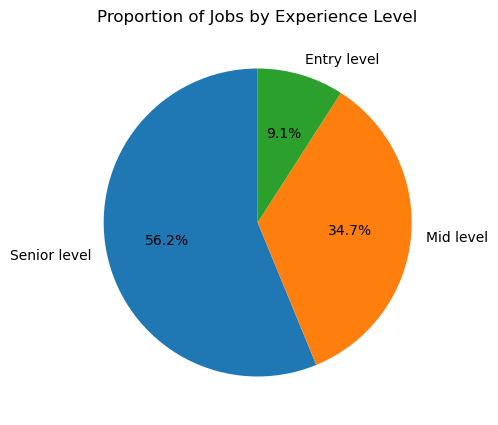

In [73]:
exp_counts = df['experience_level'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(exp_counts,labels=exp_counts.index,autopct='%1.1f%%',startangle=90)
plt.title('Proportion of Jobs by Experience Level')
plt.show()

#### --> Majority of job opportunities are concentrated in the senior-level experience (more than 10 years), indicating strong demand for highly experienced professionals.

### Rating 

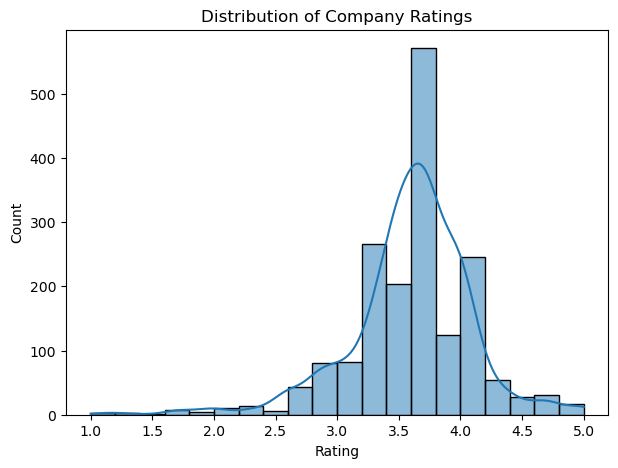

In [74]:
plt.figure(figsize=(7,5))
re= sns.histplot(df['Rating'], bins=20, kde=True)
plt.xlabel('Rating')
plt.title('Distribution of Company Ratings')
plt.show()

#### The job market is dominated by companies with average-to-good ratings, suggesting stable but competitive working environments rather than exceptional workplaces.

Text(0.5, 1.0, 'Relation between Reviews and Rating')

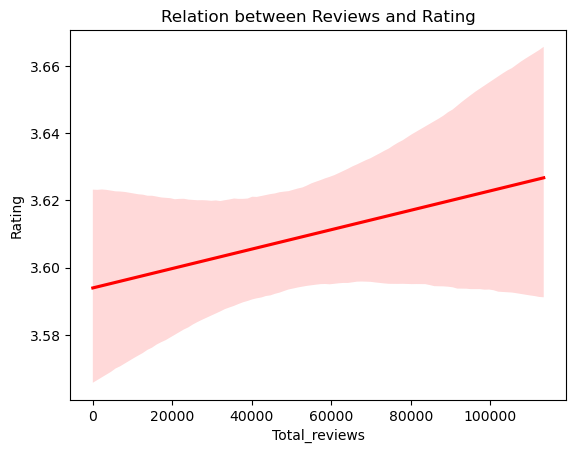

In [75]:
sns.regplot(
    x=df['Total_reviews'],
    y=df['Rating'],
    scatter=False,
    color='red')
plt.title('Relation between Reviews and Rating')

#### There is a very weak positive relationship between company reviews and ratings, indicating that higher review counts do not significantly influence company ratings.

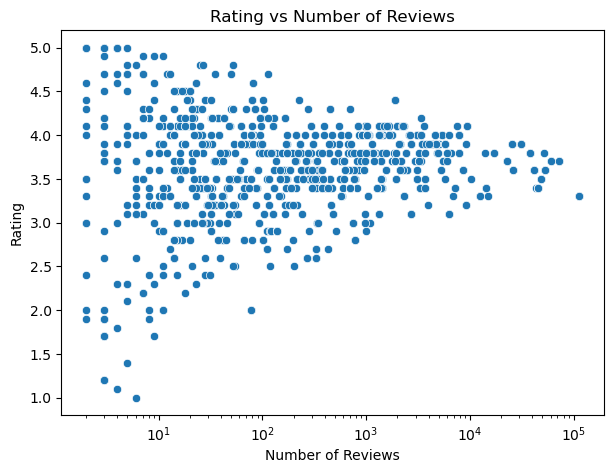

In [76]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df['Total_reviews'],y=df['Rating'])
plt.xlabel('Number of Reviews')
plt.ylabel('Rating')
plt.title('Rating vs Number of Reviews')
plt.xscale('log')  # important for skewed data
plt.show()

#### --> Companies with a higher number of reviews tend to have more stable and moderate ratings, indicating reduced bias compared to low-review companies

In [77]:
df.columns

Index(['Job_title', 'Min_Experience', 'Max_Experience', 'Location',
       'Company_name', 'Total_reviews', 'Rating', 'job_post_day', 'skills',
       'experience_level', 'location_group', 'review_segment',
       'rating_segment', 'avg_exp'],
      dtype='object')

### Experience level VS Review segment

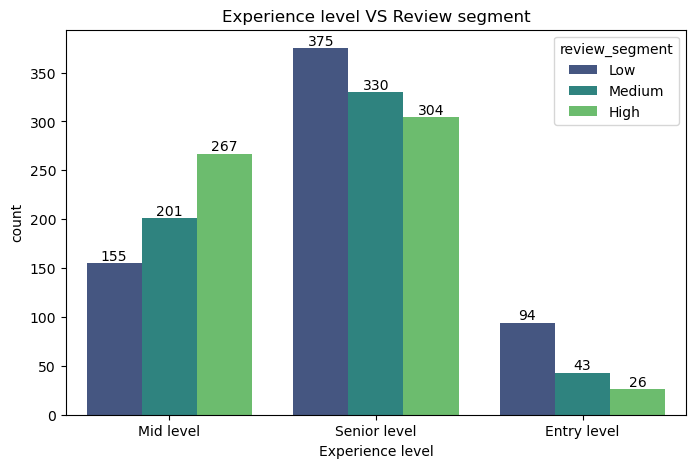

In [78]:
plt.figure(figsize=(8,5))
er=sns.countplot(x='experience_level', hue='review_segment', data =df, palette ='viridis')
for container in er.containers:
    er.bar_label(container)
plt.xlabel('Experience level')
plt.title('Experience level VS Review segment')
plt.show()

#### --> jobs in the high-review segment are more concentrated in mid and senior levels, suggesting that well-established companies prefer experienced candidates.

### Skill Demand by Experience level

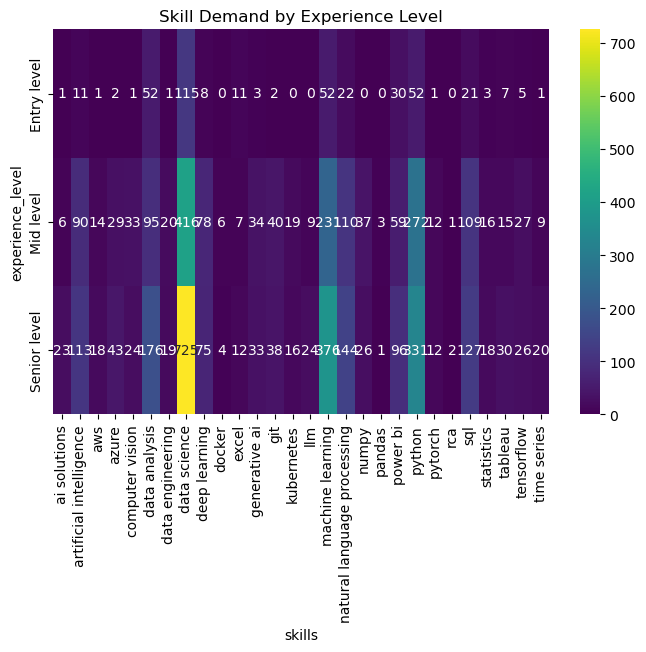

In [79]:
df_exp = df.explode('skills')

ct = pd.crosstab(df_exp['experience_level'], df_exp['skills'])

plt.figure(figsize=(8,5))
sns.heatmap(ct, annot=True, fmt='d', cmap='viridis')
plt.title('Skill Demand by Experience Level')
plt.show()

#### --> Senior-level roles focus on Data Science, Machine Learning, and Python, while entry-level roles demand Data Analysis, Data Science, Power BI, SQL, and Excel skills.

### Skill demand by Location

Text(0.5, 1.0, 'Location vs Skill Demand')

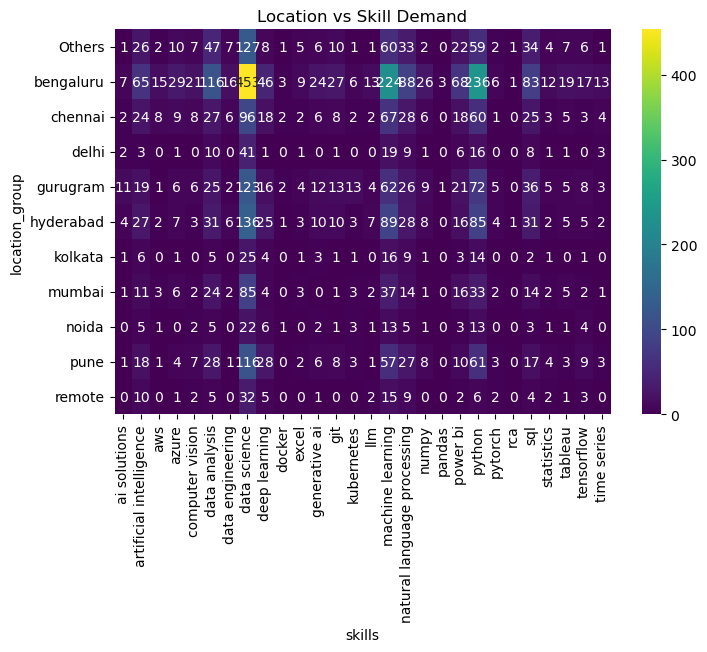

In [80]:
ct = pd.crosstab(df_exp['location_group'], df_exp['skills'])
plt.figure(figsize=(8,5))
sns.heatmap(ct, annot=True, fmt='d', cmap='viridis')
plt.title('Location vs Skill Demand')

#### --> Tech hubs show higher demand for ML and Data Science

### Experience Level vs Skill Requirements

Text(0.5, 1.0, 'Experience Level vs Skill Requirements')

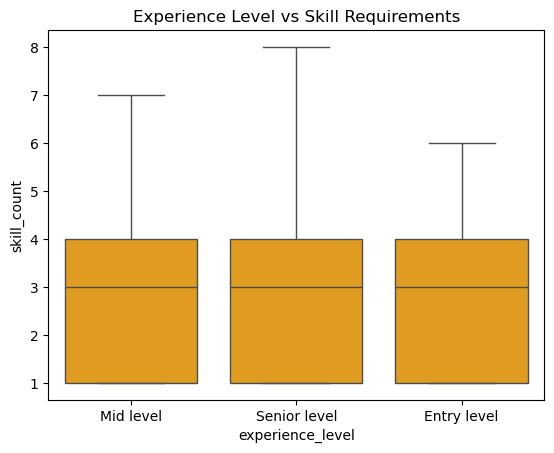

In [81]:
df['skill_count'] = df['skills'].apply(len)

sns.boxplot(x='experience_level', y='skill_count', data=df, color='orange')
plt.title('Experience Level vs Skill Requirements')

#### --> Higher experience roles require broader skillsets

### Job posting trends over time

Text(0.5, 1.0, 'Job Posting Distribution by Day')

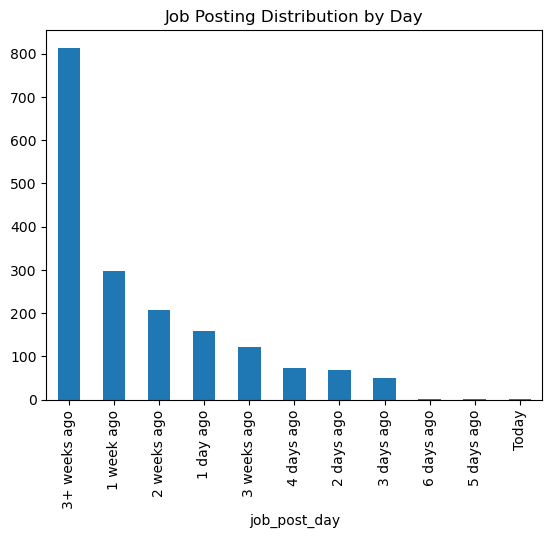

In [82]:
df['job_post_day'].value_counts().plot(kind='bar')
plt.title('Job Posting Distribution by Day')

#### --> Most job [postings in the dataset are older than 3 weeks, with very few recent listings. this indicates that the data is heavily skewed toward outdated jobs and may not accurately reflect current job market activity.

### Company hiring behavior

Text(0.5, 1.0, 'Company hiring behavior')

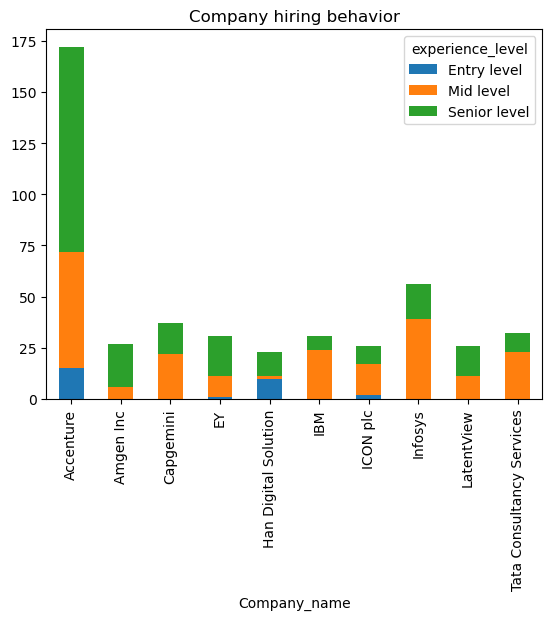

In [83]:
top_companies = df['Company_name'].value_counts().head(10).index
df_top = df[df['Company_name'].isin(top_companies)]
pd.crosstab(df_top['Company_name'], df_top['experience_level']).plot(kind='bar', stacked=True)
plt.title('Company hiring behavior')

#### --> Most companies, especially Accenture have a higher number of openings for senior-level and mid-level roles compared to Entry-level positions, indicating a stronger demand for experienced professionals in the job market.

### Multi-dimensional analysis

<Axes: xlabel='experience_level', ylabel='Rating'>

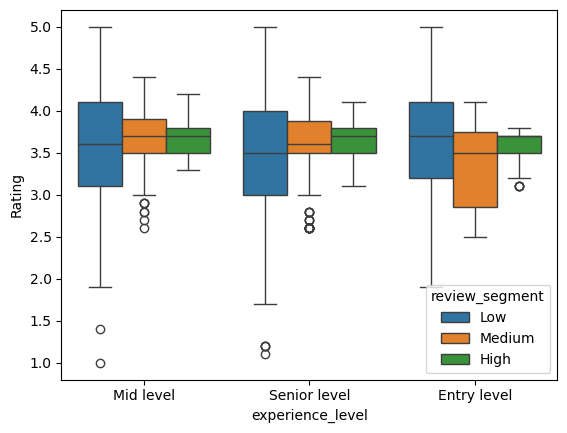

In [84]:
sns.boxplot(x='experience_level', y='Rating', hue='review_segment', data=df)

#### --> Highly reviewed companies maintain stable ratings across experience levels.

# Model Building & Evaluation

### A machine learning classification model was developed to predict job experience levels using features such as required skills, job descriptions, and location data.

#### Data preparation

In [85]:
# create a variable with selected features
df_model = df[['skills', 'location_group', 'Total_reviews', 'Rating', 'experience_level']]

# then convert the skills(list) to skills(text) for model creation
df_model['skills'] = df_model['skills'].apply(lambda x: ' '.join(x))

# Label encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_model['experience_level'] = le.fit_transform(df_model['experience_level'])

# Train and Test split
from sklearn.model_selection import train_test_split
X = df_model.drop('experience_level', axis=1)
y = df_model['experience_level']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Then doing the preprocessing 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

preprocessor = ColumnTransformer([
    ('text', TfidfVectorizer(), 'skills'),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['location_group']),
    ('num', 'passthrough', ['Total_reviews', 'Rating'])
])

# Building the model
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

# Train Model 
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

C:\Users\alpan\AppData\Local\Temp\ipykernel_14012\1816374961.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['skills'] = df_model['skills'].apply(lambda x: ' '.join(x))
C:\Users\alpan\AppData\Local\Temp\ipykernel_14012\1816374961.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['experience_level'] = le.fit_transform(df_model['experience_level'])


Accuracy: 0.6547884187082406
              precision    recall  f1-score   support

           0       0.71      0.35      0.47        49
           1       0.58      0.56      0.57       146
           2       0.69      0.77      0.73       254

    accuracy                           0.65       449
   macro avg       0.66      0.56      0.59       449
weighted avg       0.65      0.65      0.65       449



#### --> The model achieved an overall accuracy of 65% with strongest performance in predicting senior-level roles. However, lower recall for entry-level positions indicates class imbalance and less distinctive feature patterns for fresher roles

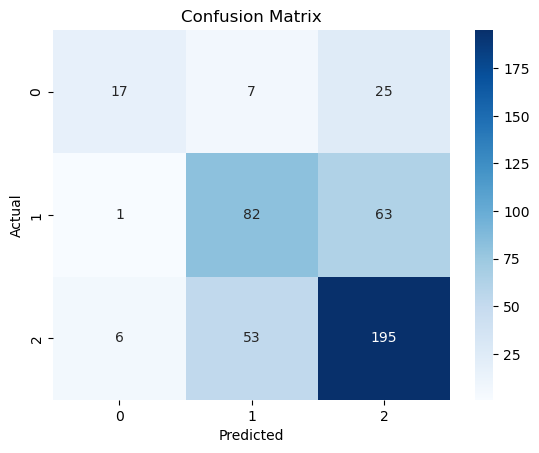

In [87]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#### --> The model predicts Senior-level roles (class 2) with the highest accuracy, correctly classifying 150 instances.
#### --> Mid-level roles show reasonable prediction performance, but a significant number are misclassified as Senior roles.
#### --> The model struggles to accurately classify Entry-level roles, with many being misclassified as Senior roles.
#### --> The model tends to over-predict Senior-level roles, indicating a possible class imbalance or feature dominance.

### The model demonstrates strong performance in identifying senior-level roles but shows limitations in distinguishing entry and mid-level positions, highlighting the need for improved feature engineering and class balancing.

In [88]:
df.to_csv('final_dataset.csv', index=False)

In [89]:
df_model['Predicted_Level'] = model.predict(X)
df_model.to_csv('model_output.csv', index=False)

C:\Users\alpan\AppData\Local\Temp\ipykernel_14012\1500051119.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['Predicted_Level'] = model.predict(X)


In [90]:
import os
os.getcwd()

'C:\\Users\\alpan\\anaconda_projects\\d066b04f-01a6-47f1-bb97-d2502c45bac7'

In [94]:
import pandas as pd

results = pd.DataFrame({
    'Class': ['Entry (0)', 'Mid (1)', 'Senior (2)'],
    'Precision': [0.71, 0.58, 0.69],
    'Recall': [0.35, 0.56, 0.77],
    'F1 Score': [0.47, 0.57, 0.73],
    'Support': [49, 146, 254]
})

results.to_csv("model_results.csv", index=False)

In [95]:
accuracy = pd.DataFrame({'Metric': ['Accuracy'], 'Value': [0.67]})
accuracy.to_csv("accuracy.csv", index=False)

In [96]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(cm,
                     columns=['Pred_0','Pred_1','Pred_2'],
                     index=['Actual_0','Actual_1','Actual_2'])

cm_df.to_csv("confusion_matrix.csv")